<a href="https://colab.research.google.com/github/katzemelli/thesis-edit-distance-nn/blob/main/notebooks/first_experiment_paper_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/thesis-edit-distance-nn/"
MODEL_PATH = BASE_PATH + "models/"
DATA_PATH = BASE_PATH + "data/"

Mounted at /content/drive


In [1]:
import os

# Clone your repo into Colab's working directory
!git clone https://github.com/katzemelli/thesis-edit-distance-nn.git

# Move into the repo folder
os.chdir('/content/thesis-edit-distance-nn')

# Confirm you're in the right place
!ls

# Confirm that CSV files are inside sampledata/
!ls sampledata/

Cloning into 'thesis-edit-distance-nn'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 25 (delta 6), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 14.64 KiB | 7.32 MiB/s, done.
Resolving deltas: 100% (6/6), done.
notebooks  README.md  requirements.txt	sampledata
desired_length_2_levenshtein_2.csv    predtime_length_5_4_levenshtein.csv
desired_length_2_levenshtein.csv      predtime_length_5_levenshtein.csv
predtime_length_10_2_levenshtein.csv


fatal: not a git repository (or any of the parent directories): .git


In [1]:
!pip install tensorflow ml_dtypes --upgrade

In [2]:
import tensorflow as tf
# test to see if tensorflow exists
print(tf.__version__)  # should be 2.x

2.19.0


# **Levenshtein NN Architecture**
This [paper](https://ieeexplore.ieee.org/document/11272136) [implements a constructive ReLU network](https://github.com/itezaP/reluedit/tree/main) where the weights are analytically derived to implement the Levenshtein DP algorithm exactly. The key insights are here:

*   *matching_module()* computes whether two characters are equal, using fixed, hand-set ReLU weights.
*   *min_module()* computes the minimum of two values using ReLU arithmetic.
*   *align_model_for_N()* wires these togehter to mirrow the exact DP table structure.

The paper's claim is:
*Given a fixed input string x and a distance d, can the network learn the weights that represent the string y?*

*for_gen_dense* weights are the string y in disguise.

The following code is taken from the papers [github repository](https://github.com/itezaP/reluedit/tree/main) using the training data provided:




In [9]:
import random
import time
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import statistics
from sklearn.model_selection import KFold

# import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Input, add, ThresholdedReLU, Lambda, Reshape, concatenate, Cropping1D, Flatten, LeakyReLU, ELU
from tensorflow.python.client import device_lib

def transform_seqs_to_input(seqA, seqB):
    matching_pairs = []
    input_length_x = 0

    matching_pairs.append([int(seqA[0]), int(seqB[0])])
    if len(seqA) == 1 and len(seqB) == 1:
        return matching_pairs
    else:
        input_length_x = len(seqA)
        match_layers_i = (input_length_x * 2) - 1

    start_i = 1
    end_i = 2

    for l in range(match_layers_i):
        if l < input_length_x - 1:
            i, j = [*reversed(range(0, end_i))], [*range(0, end_i)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            end_i += 1
        else:
            i, j = [*reversed(range(start_i, input_length_x))], [*range(start_i, input_length_x)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            start_i += 1
            if start_i > len(seqB):
                break

    return matching_pairs

def transform_input_for_generate(input):
    x = []
    y = []
    for pair in input:
        x.append(pair[0])
        y.append(pair[1])
    return [x, y]

def matching_module():
    epsilon = 1

    model = Sequential()
    model.add(Dense(units=2, activation='relu', use_bias=True, input_shape=(2,)))
    model.add(Dense(units=2, activation='relu', use_bias=True))
    model.add(Dense(units=1, activation='relu', use_bias=True))

    w1 = model.layers[0].get_weights()
    w1[0][0][0], w1[0][0][1] = 1.0, -1.0
    w1[0][1][0], w1[0][1][1] = -1.0, 1.0
    w1[1][0], w1[1][1] = 0, 0
    w2 = model.layers[1].get_weights()
    w2[0][0][0], w2[0][0][1] = 1.0, 1.0
    w2[0][1][0], w2[0][1][1] = 1.0, 1.0
    w2[1][0], w2[1][1] = epsilon, -1 * epsilon
    w3 = model.layers[2].get_weights()
    w3[0][0][0], w3[0][1][0] = (1.0/epsilon), -1.0 * (1.0/epsilon)
    w3[1][0] = -1

    model.layers[0].set_weights(w1)
    model.layers[1].set_weights(w2)
    model.layers[2].set_weights(w3)

    model.trainable = False

    return model

def min_module(i, j, k):
    input = Input(shape=(2,))
    x = Dense(2, activation='relu', use_bias=True)(input)
    combined = concatenate([x, input])

    layer_name = 'result_pixel_' + str(i) + str(j) + '_' + str(k)
    z = Dense(1, activation='relu', use_bias=True, name=layer_name)(combined)
    model = Model(inputs=input, outputs=z)

    w1 = model.layers[1].get_weights()
    w1[0][0], w1[0][1] = [-1.0, 1.0], [1.0, -1.0]
    w2 = model.layers[3].get_weights()
    w2[0][0], w2[0][1], w2[0][2], w2[0][3] = -0.5, -0.5, 0.5, 0.5

    model.layers[1].set_weights(w1)
    model.layers[3].set_weights(w2)

    model.trainable = False

    return model

def minimum(i, j):
    input = Input(shape=(3,))
    comp1_pair = Lambda(lambda x: x[:, :2], output_shape=(2,))(input)
    comp2_input = Lambda(lambda x: x[:, 2:], output_shape=(1,))(input)

    m = min_module(i, j, 1)(comp1_pair)
    comp2_pair = concatenate([comp2_input, m])
    output = min_module(i, j, 2)(comp2_pair)

    model = Model(inputs=input, outputs=output)
    model.trainable = False
    return model

def align_model_for_N(seq_length_x, seq_length_y, matching_pair_number):
    import tensorflow as tf
    from tensorflow.keras.layers import Lambda, Dense, concatenate, Flatten, Input

    input = Input(shape=(2, matching_pair_number), name='input')

    # Extract x (row 0) and y (row 1) — both shape (None, matching_pair_number)
    y = Lambda(lambda t: t[:, 1, :], output_shape=(matching_pair_number,))(input)
    x = Lambda(lambda t: t[:, 0, :], output_shape=(matching_pair_number,))(input)

    out = {}
    start_i = 0
    step = 2
    for i in range(seq_length_y):
        a = start_i
        layername = 'for_gen_dense_' + str(i + 1)
        # Slice column a from y → shape (None, 1), then Dense(1) → (None, 1)
        y_slice = Lambda(lambda t, a=a: t[:, a:a+1], output_shape=(1,))(y)
        z = Dense(1, activation='relu', name=layername, use_bias=False)(y_slice)
        out[layername] = z  # shape: (None, 1)
        start_i += step
        step += 1

    pair_i = 1
    cropping_start_i = 0

    calc_layer = (seq_length_x * 2) - 1
    test_dict = {}

    # --- First pixel (1,1) ---
    y_dense_layer_name = 'for_gen_dense_1'
    densed_y = out[y_dense_layer_name]  # (None, 1)

    # x_char: slice column 0 from x → (None, 1)
    x_char = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(x)

    debug_name = 'matching_debug_1'
    pair_11 = concatenate([x_char, densed_y], name=debug_name)  # (None, 2)

    ext_gaps = Dense(2, activation='relu', name='first_calc_gap_layer')(pair_11)  # (None, 2)

    min1 = min_module(1, 1, 1)(ext_gaps)           # (None, 1)
    matching1 = matching_module()(pair_11)           # (None, 1)
    combined = concatenate([min1, matching1])        # (None, 2)
    z = min_module(1, 1, 2)(combined)               # (None, 1)
    result_pixel_11 = concatenate([ext_gaps, z], name='input_pixel_1_1')  # (None, 3)

    pair_i = 2

    if seq_length_x == 1 and seq_length_y == 1:
        output = z
        return Model(inputs=input, outputs=output)
    else:
        test_dict['input_pixel_1_1'] = result_pixel_11
        test_dict['result_pixel_1_1'] = z

        comp_i_val, comp_j_val = 1, 2
        start_sentinel, end_sentinel = 1, 2
        unbalance_flag = True

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_length_x - 1:
                comp_i_val, comp_j_val = start_sentinel, end_sentinel
                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_i = comp_i_val
                        y_dense_layer_name = 'for_gen_dense_' + str(y_i)
                        densed_y = out[y_dense_layer_name]  # (None, 1)

                        # x_char: slice column (c-1) from x → (None, 1)
                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)

                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)  # (None, 2)
                        matching = matching_module()(pair)  # (None, 1)

                        if comp_i_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_input = test_dict[previous_input_pixel_name]   # (None, 3)
                            previous_result = test_dict[previous_result_pixel_name] # (None, 1)
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)  # (None, 1)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)  # (None, 3)

                        elif comp_j_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_input = test_dict[previous_input_pixel_name]
                            previous_result = test_dict[previous_result_pixel_name]
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)

                        else:
                            previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                            previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                            previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                            before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation='relu', name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                if end_sentinel + 1 <= seq_length_x:
                    end_sentinel += 1

            else:
                start_sentinel += 1
                comp_i_val, comp_j_val = start_sentinel, end_sentinel

                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_dense_layer_name = 'for_gen_dense_' + str(comp_i_val)
                        densed_y = out[y_dense_layer_name]

                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)
                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)
                        matching = matching_module()(pair)

                        previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                        previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                        previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                        before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation='relu', name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                    if start_sentinel == end_sentinel:
                        return Model(inputs=input, outputs=result_pixel)

def set_weight_for_debug(model, seq_len_x, seq_len_y, matching_pair):
    print('setting weigths ...')

    for i in range(seq_len_y):
        lname = 'for_gen_dense_' + str(i+1)
        weights = model.get_layer(lname).get_weights()
        #weights[0][0][0] = 1

        weights[0][0][0] = random.uniform(0,1)
        model.get_layer(lname).set_weights(weights)

    w = model.get_layer('first_calc_gap_layer').get_weights()
    w[0][0][0], w[0][0][1] = 0, 0
    w[0][1][0], w[0][1][1] = 0, 0
    w[1][0], w[1][1] = 2, 2
    model.get_layer('first_calc_gap_layer').set_weights(w)
    model.get_layer('first_calc_gap_layer').trainable = False

    if seq_len_x > 1:
        calc_layer = (seq_len_x * 2) - 1
        comp_i, comp_j = 1, 2
        start_sentinel, end_sentinel = 1, 2

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_len_x - 1:
                comp_i, comp_j = start_sentinel, end_sentinel
                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)
                        w = model.get_layer(input_layer_name).get_weights()
                        if comp_i == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        elif comp_j == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        else:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, 0

                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)
                if end_sentinel + 1 <= seq_len_x:
                    end_sentinel += 1
            else:
                start_sentinel = start_sentinel + 1
                comp_i, comp_j = start_sentinel, end_sentinel

                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)

                        w = model.get_layer(input_layer_name).get_weights()
                        w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                        w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                        w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                        w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                        w[1][0], w[1][1], w[1][2] = 1, 1, 0
                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)

def froozen_align_model(model):
    print('froozen parameters in a network for alignment ...')
    layers = model.layers
    for layer in layers:
        if 'for_gen_dense' in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

def measure_cnst_model():
    SEQ_LEN_X = 10
    SEQ_LEN_Y = 2
    PAIRS_LEN = SEQ_LEN_X * SEQ_LEN_Y

    N = 5
    times = []
    average = 0
    for i in range(N):
        cnst_model_s_time = time.perf_counter()
        model = align_model_for_N(SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
        cnst_model_e_time = time.perf_counter() - cnst_model_s_time

        set_weight_for_debug(model, SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)

        average += cnst_model_e_time
        times.append(cnst_model_e_time)

    print(N, 'trial average construct model time:', average / N)
    print('min=', min(times), 'max=', max(times), np.argmax(times), 'median=', np.median(times), 'std=', np.std(times))

def measure():
    filename = './sampledata/predtime_length_10_2_levenshtein.csv'
    print('test file :', filename)

    lines = []
    with open(filename, 'r') as f:
        for line in f:
            line.rstrip('\n')
            lines.append(line)

    confirm_l = lines[0]
    sp = confirm_l.split(',')
    x, y = sp[0], sp[1]
    pairs = transform_seqs_to_input(x, y)
    SEQ_LEN_X = len(x)
    SEQ_LEN_Y = len(y)
    PAIRS_LEN = len(pairs)

    model = align_model_for_N(SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    set_weight_for_debug(model, SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    froozen_align_model(model)

    N = 500
    perform_data = []
    if len(lines) < N:
        shortage_times = math.ceil(N / len(lines))
        perform_data = lines * shortage_times
        perform_data = perform_data[:N]
    else:
        perform_data = lines[:N]

    average_time = 0
    correct = 0
    times = []
    for data in perform_data:
        testdata = data
        sp = testdata.split(',')
        x, y, c_score = sp[0], sp[1], int(sp[2])
        input = transform_seqs_to_input(x, y)
        extra_input = [transform_input_for_generate(input)]

        x = tf.constant(extra_input)
        s_time = time.perf_counter()
        p_score = model(x, training=False)
        e_time = time.perf_counter() - s_time
        average_time += e_time
        times.append(e_time)

        p_score = int(p_score[0][0])
        if int(p_score) == c_score:
            correct += 1
        else:
            print('valid :', x, y, p_score, c_score)
    print('correct :', correct)

    average_time = average_time / N
    print(N, 'samples average time:', round(average_time, 3))
    print('min=', min(times), 'max=', max(times), np.argmax(times), 'median=', np.median(times), 'std=', np.std(times))

def plot_progress_weights(progress_weights, epoch, desire):
    x = [*range(epoch+1)]

    color_cycle = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    markers = ['o', 's', '^', 'v', '*']
    plt.figure(figsize=(18, 10), dpi=100)

    y_s = np.array(progress_weights).T
    w_i = 0
    for y in y_s:
        m = markers[w_i%len(markers)]
        plt.plot(x, y, marker=m, label="weigth" + str(w_i+1), color=color_cycle[w_i])
        plt.hlines(desire[w_i], 0, epoch, color=color_cycle[w_i] ,linestyles='dotted')
        w_i += 1

    plt.xlabel('epochs')
    plt.ylabel('weight')
    plt.ylim(-0.5,1.5)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=10)
    plt.savefig('weights.png')

def training():
    # data and model setting
    EPOCHS = 20
    DESIRE = '11'
    LEN = len(DESIRE)

    filename = './sampledata/desired_length_' + str(LEN) + '_levenshtein_2.csv'
    lines = []
    with open(filename, 'r') as f:
        for line in f:
            line.rstrip('\n')
            lines.append(line)

    confirm_l = lines[0]
    sp = confirm_l.split(',')
    x, y = sp[0], sp[1]
    pairs = transform_seqs_to_input(x, y)
    SEQ_LEN_X = len(x)
    SEQ_LEN_Y = len(y)
    PAIRS_LEN = len(pairs)

    model = align_model_for_N(SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    set_weight_for_debug(model, SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    froozen_align_model(model)
    #model.summary()

    init_trained_weights = []
    for layer in model.layers:
        if 'for_gen_dense' in layer.name:
            weight = layer.get_weights()
            init_trained_weights.append(float(weight[0][0]))
    init_trained_weights.reverse()

    progress_weights = []
    progress_weight = []
    for i in range(LEN):
        lname = 'for_gen_dense_' + str(i+1)
        weights = model.get_layer(lname).get_weights()
        progress_weight.append(weights[0][0][0])
    progress_weights.append(progress_weight)

    #optimizer = tf.keras.optimizers.Adam(lr=0.1, beta_1=0.9, beta_2=0.999, epsilon=0.1)
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
    loss_fn = tf.keras.losses.MeanSquaredError()

    progress_grads = []
    for epoch in range(EPOCHS):
        print('Epoch', epoch)

        loss = tf.Variable(0.0, name='loss')
        with tf.GradientTape() as tape:
            for line in lines:
                sp = line.split(',')
                x, y, true_score = sp[0], sp[1], int(sp[2])
                input = transform_seqs_to_input(x, y)
                input = transform_input_for_generate(input) # changed pairs -> input bugfix
                input = tf.constant([input])
                logit = model(input, training=True)
                loss = loss + loss_fn(true_score, logit)
            batch_loss = loss / len(lines)
            print(batch_loss)
            grads = tape.gradient(batch_loss, model.trainable_weights)
            #print(grads)
            optimizer.apply_gradients(zip(grads, model.trainable_weights))

            progress_grad = []
            for grad in grads:
                progress_grad.append(float(grad[0][0]))
            progress_grads.append(progress_grad)

        progress_weight = []
        for i in range(LEN):
            lname = 'for_gen_dense_' + str(i+1)
            weights = model.get_layer(lname).get_weights()
            progress_weight.append(weights[0][0][0])
        progress_weights.append(progress_weight)

    raw_trained_weights = []
    for layer in model.layers:
        if 'for_gen_dense' in layer.name:
            weight = layer.get_weights()
            raw_trained_weights.append(float(weight[0][0]))
    raw_trained_weights.reverse()

    print('init weights:', init_trained_weights)
    print('raw trained weights:', raw_trained_weights)

    d = [int(i) for i in DESIRE]
    print(progress_weights)
    plot_progress_weights(progress_weights, EPOCHS, d)

# Run training() only
**What to expect:**

Output should look something like this:
```
setting weigths ...
Epoch 0
tf.Tensor(0.123, shape=(), dtype=float32)
Epoch 1
...
init weights: [0.73, 0.45]
raw trained weights: [0.92, 0.87]
```
And it will save a weights.png plot to working directory showing the two weights converging toward [1, 1] (which is the binary encoding of DESIRE = '11').


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


setting weigths ...
froozen parameters in a network for alignment ...
Epoch 0


/tmp/ipykernel_3559/3926954037.py:494: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  init_trained_weights.append(float(weight[0][0]))


tf.Tensor(1.3389468, shape=(), dtype=float32)
Epoch 1
tf.Tensor(0.85692596, shape=(), dtype=float32)
Epoch 2
tf.Tensor(0.5484326, shape=(), dtype=float32)
Epoch 3
tf.Tensor(0.3509969, shape=(), dtype=float32)
Epoch 4
tf.Tensor(0.22463797, shape=(), dtype=float32)
Epoch 5
tf.Tensor(0.14376837, shape=(), dtype=float32)
Epoch 6
tf.Tensor(0.09201175, shape=(), dtype=float32)
Epoch 7
tf.Tensor(0.058887504, shape=(), dtype=float32)
Epoch 8
tf.Tensor(0.037688036, shape=(), dtype=float32)
Epoch 9
tf.Tensor(0.024120327, shape=(), dtype=float32)
Epoch 10
tf.Tensor(0.015437011, shape=(), dtype=float32)
Epoch 11
tf.Tensor(0.00987969, shape=(), dtype=float32)
Epoch 12
tf.Tensor(0.006322999, shape=(), dtype=float32)
Epoch 13
tf.Tensor(0.004046707, shape=(), dtype=float32)
Epoch 14
tf.Tensor(0.0025898926, shape=(), dtype=float32)
Epoch 15
tf.Tensor(0.0016575365, shape=(), dtype=float32)
Epoch 16
tf.Tensor(0.0010608163, shape=(), dtype=float32)
Epoch 17
tf.Tensor(0.0006789253, shape=(), dtype=float32)

/tmp/ipykernel_3559/3926954037.py:545: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  raw_trained_weights.append(float(weight[0][0]))


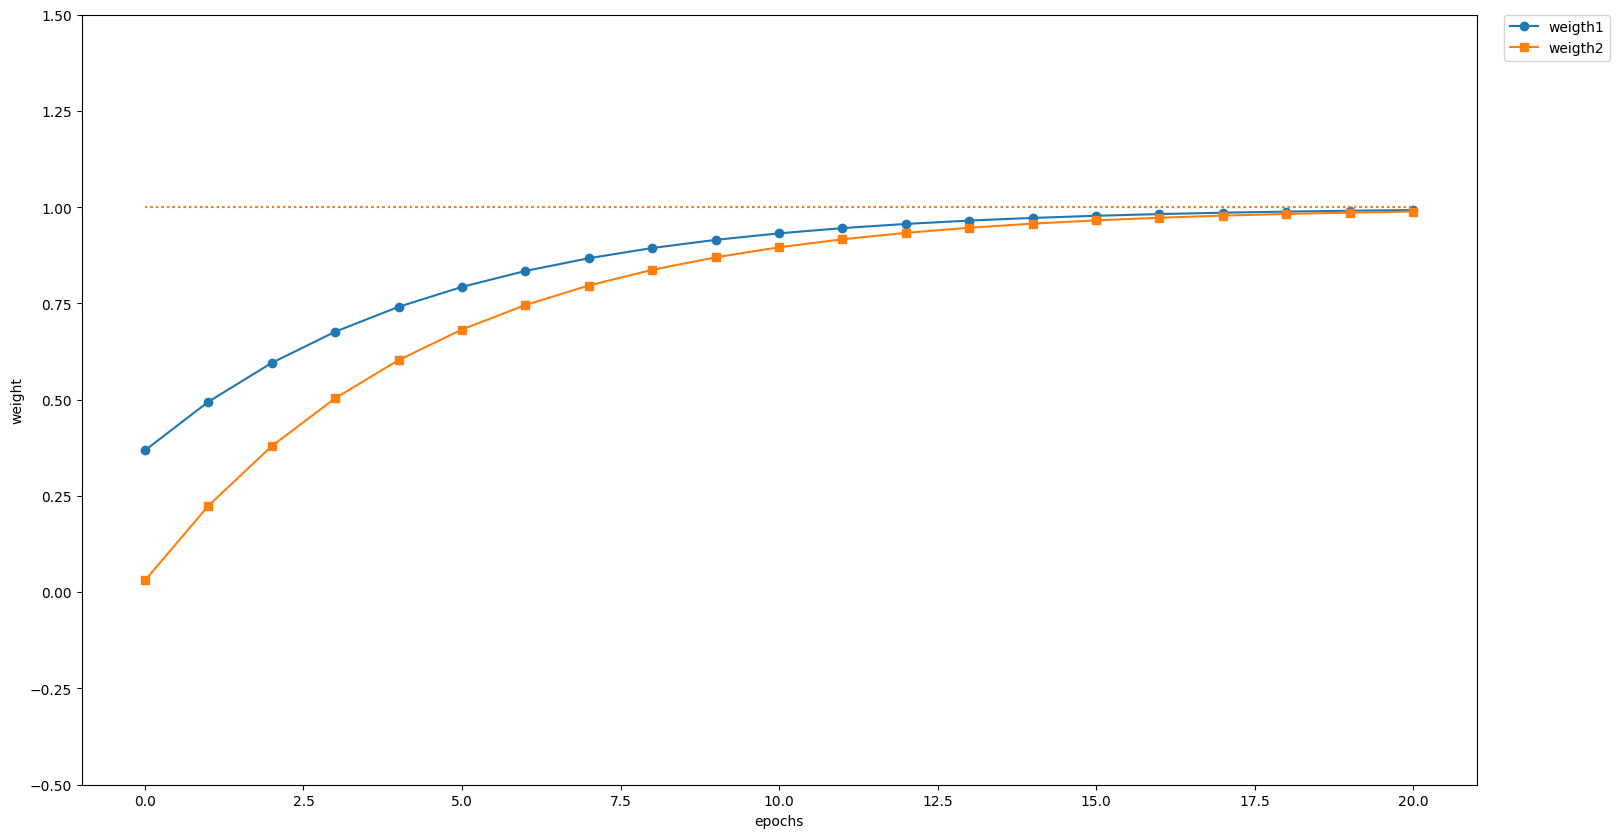

In [10]:
def main():
    #measure_cnst_model()
    #measure()
    training()

main()